# 实践项目 06：空间细胞通讯候选关系

我们使用小鼠肾脏空间转录组结果，检查细胞位置、细胞类型、配体—受体和候选通讯方向。配套研究使用三层图网络训练。本次实践保留读懂数据与结果所需的关键步骤，可以在普通电脑上完成。

Kaggle 是首选运行环境。把题目 Notebook 复制到自己的账户并添加配套数据集，按顺序完成对应任务的单元格。

## 任务总览

1. 核对细胞表和候选边表，查看 H&E 与细胞坐标。
2. 筛选 `Vegfa-Flt1/Kdr`，计算可解释的距离—共表达分数。
3. 按发送和接收细胞类型汇总有方向的候选关系。
4. 绘制空间候选边并结合遮边测试指标解释结果边界。

候选分数只表示当前数据中的相对优先级。RNA 表达、空间邻近和数据库记录不能直接证明蛋白结合或下游通路已经激活。


In [1]:
from pathlib import Path  # 处理 Kaggle 与本地文件路径
import json  # 读取并保存结果摘要
import numpy as np  # 进行数组与数值计算
import pandas as pd  # 读取细胞表和候选通讯边表
import matplotlib.pyplot as plt  # 绘制组织、热图和空间关系


def find_file(name):  # 在 Kaggle 数据集或本地项目目录中寻找指定文件
    roots = [Path('/kaggle/input'), Path.cwd(), Path.cwd() / '数据', Path.cwd() / 'data', Path.cwd().parent / '数据', Path.cwd().parent / 'data']  # 同时兼容项目根目录和实践/答案子目录
    for root in roots:  # 遍历可能的数据根目录
        if not root.exists():  # Kaggle 之外的环境可能没有 /kaggle/input
            continue  # 跳过不存在的目录
        matches = list(root.rglob(name))  # 递归查找文件，兼容 Kaggle 自动添加的数据集目录名
        if matches:  # 找到后立即返回第一项
            return matches[0]  # 返回实际文件路径
    raise FileNotFoundError(f'没有找到 {name}，请确认已添加项目数据集。')  # 给出可操作的错误信息

LOCAL_PROJECT = Path.cwd().parent if (Path.cwd().parent / '数据').exists() else Path.cwd()  # 从实践/答案子目录运行时回到项目根目录
OUT = Path('/kaggle/working') if Path('/kaggle/working').exists() else LOCAL_PROJECT / '结果'  # Kaggle 与本地共用输出规则
OUT.mkdir(parents=True, exist_ok=True)  # 确保结果目录存在


cells = pd.read_csv(find_file('ccc_cells.csv'))  # 每行是一枚细胞，包含坐标与细胞类型
edges = pd.read_csv(find_file('ccc_edges.csv'))  # 每行是一条有方向的候选配体—受体边
history = pd.read_csv(find_file('ccc_training_history.csv'))  # 配套图网络的训练记录
metrics = json.loads(find_file('ccc_model_metrics.json').read_text(encoding='utf-8'))  # 配套遮边测试指标
source_manifest = json.loads(find_file('source_manifest.json').read_text(encoding='utf-8'))  # 读取原图与预览图的尺寸关系
he_image = plt.imread(find_file('ccc_kidney_he.png'))  # 读取肾脏 H&E 预览图
print('cells:', cells.shape, 'edges:', edges.shape)  # 先确认数据已经成功加载


cells: (6655, 5) edges: (16959, 20)


## 任务 1：细胞与候选边核对

输出细胞数、细胞类型数、候选边数、配体—受体对数和低置信度注释比例，并把细胞坐标叠加到 H&E 预览图。观察坐标范围与图像范围是否相符。

参考写法保留同一输入和输出，先核对数值，再阅读图像。


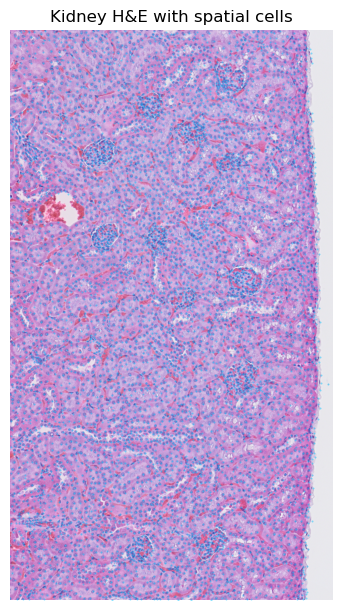

{'cells': 6655, 'cell_types': 14, 'candidate_edges': 16959, 'lr_pairs': 506, 'low_confidence_cells': 1045}


In [2]:
summary = {  # 汇总输入规模和关键数据质量信息
    'cells': int(len(cells)),  # 记录细胞数量
    'cell_types': int(cells['cell_type'].nunique()),  # 记录细胞类型数量
    'candidate_edges': int(len(edges)),  # 记录前20%候选边数量
    'lr_pairs': int(edges['lr_pair'].nunique()),  # 记录出现过的配体—受体对数量
    'low_confidence_cells': int(cells['low_confidence'].astype(bool).sum()),  # 记录低置信度注释细胞
}
fig, ax = plt.subplots(figsize=(7.2, 6.2))  # 创建组织坐标图
ax.imshow(he_image)  # 显示 H&E 预览图
scale_x = source_manifest['preview_he_size'][0] / source_manifest['original_he_size'][0]  # 计算横向缩放比例
scale_y = source_manifest['preview_he_size'][1] / source_manifest['original_he_size'][1]  # 计算纵向缩放比例
tissue_mask = np.ptp(he_image[..., :3], axis=-1) > .05  # 用染色饱和度区分组织与灰白玻片背景
tissue_x = np.where(tissue_mask.mean(axis=0) > .05)[0]  # 排除玻片背景中的零散深色像素
tissue_y = np.where(tissue_mask.mean(axis=1) > .05)[0]  # 保留每行具有稳定组织覆盖的范围
display_x = cells['X'] * scale_x; display_y = cells['Y'] * scale_y  # 得到预览图中的细胞坐标
margin = 35  # 在组织边界外保留少量背景，避免大面积空白压缩组织细节
view_x = (max(0, tissue_x.min() - margin), min(he_image.shape[1], tissue_x.max() + margin))  # 以组织边界确定横向显示范围
view_y = (max(0, tissue_y.min() - margin), min(he_image.shape[0], tissue_y.max() + margin))  # 以组织边界确定纵向显示范围
ax.scatter(display_x, display_y, s=2, c='deepskyblue', alpha=.45, linewidths=0)  # 按预览尺寸叠加细胞坐标
ax.set_xlim(*view_x); ax.set_ylim(view_y[1], view_y[0])  # 聚焦有细胞的组织区域并保持图像纵轴方向
ax.set_title('Kidney H&E with spatial cells')  # 标明图像内容
ax.axis('off')  # 隐藏像素坐标刻度
fig.tight_layout()  # 调整图像边距
fig.savefig(OUT / 'task1_data_overview.png', dpi=160)  # 保存网页和结果核对图
plt.show()  # 在 Notebook 中显示图像
print(summary)  # 显示数据核对结果


## 任务 2：Vegfa–Flt1/Kdr 候选证据

保留发送配体为 `Vegfa`、接收受体为 `Flt1` 或 `Kdr` 的边。使用 `log1p(共表达) × exp(-距离/120)` 得到可解释分数，再与配套 `evidence_score` 比较。

参考写法保留同一输入和输出，先核对数值，再阅读图像。


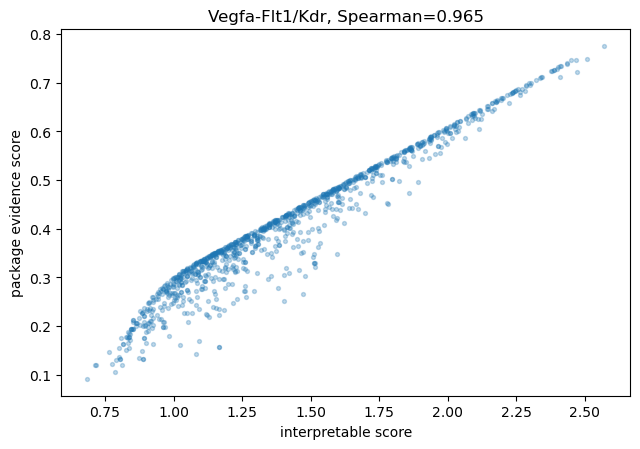

{'case_edges': 1077, 'spearman': 0.9654}


In [3]:
case_edges = edges[(edges['ligand'] == 'Vegfa') & edges['receptor'].isin(['Flt1', 'Kdr'])].copy()  # 筛选肾小球相关候选边
case_edges['simple_score'] = np.log1p(case_edges['coexpression']) * np.exp(-case_edges['distance'] / 120.0)  # 组合共表达与距离衰减
spearman = case_edges[['simple_score', 'evidence_score']].corr(method='spearman').iloc[0, 1]  # 比较两个证据分数的排序
fig, ax = plt.subplots(figsize=(6.5, 4.6))  # 创建证据比较图
ax.scatter(case_edges['simple_score'], case_edges['evidence_score'], s=8, alpha=.28)  # 显示每条候选边
ax.set(xlabel='interpretable score', ylabel='package evidence score', title=f'Vegfa-Flt1/Kdr, Spearman={spearman:.3f}')  # 标注坐标和相关性
fig.tight_layout()  # 调整图像边距
fig.savefig(OUT / 'task2_evidence_comparison.png', dpi=160)  # 保存证据比较图
plt.show()  # 在 Notebook 中显示图像
print({'case_edges': len(case_edges), 'spearman': round(float(spearman), 4)})  # 输出可复查数值


## 任务 3：细胞类型方向汇总

一条边同时包含发送类型和接收类型。按这两个字段汇总平均 `gnn_score` 和边数，绘制方向热图；行与列互换时含义也会互换。

参考写法保留同一输入和输出，先核对数值，再阅读图像。


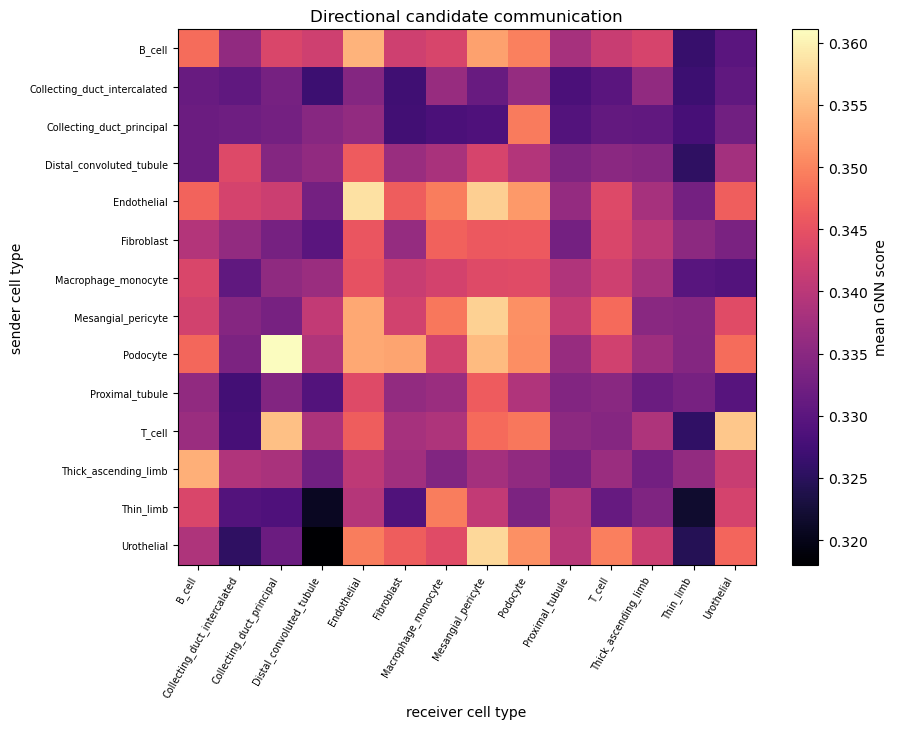

            src_cell_type              dst_cell_type  mean_score  edge_count
114              Podocyte  Collecting_duct_principal    0.361073           7
60            Endothelial                Endothelial    0.358518         310
189            Urothelial         Mesangial_pericyte    0.357666           5
105    Mesangial_pericyte         Mesangial_pericyte    0.356874         172
63            Endothelial         Mesangial_pericyte    0.356775         153
153                T_cell                 Urothelial    0.356136           7
142                T_cell  Collecting_duct_principal    0.355409           7
119              Podocyte         Mesangial_pericyte    0.354932         288
4                  B_cell                Endothelial    0.354232          32
154  Thick_ascending_limb                     B_cell    0.353896          20


In [4]:
communication = (edges.groupby(['src_cell_type', 'dst_cell_type'])  # 按发送与接收类型分组
                 .agg(mean_score=('gnn_score', 'mean'), edge_count=('gnn_score', 'size'))  # 同时保留平均分和边数
                 .reset_index())  # 恢复为普通表格
heatmap = communication.pivot(index='src_cell_type', columns='dst_cell_type', values='mean_score').fillna(0)  # 形成方向矩阵
fig, ax = plt.subplots(figsize=(9.2, 7.4))  # 创建热图
image = ax.imshow(heatmap.values, cmap='magma', aspect='auto')  # 显示平均候选分数
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns, rotation=60, ha='right', fontsize=7)  # 标注接收类型
ax.set_yticks(range(len(heatmap.index)), heatmap.index, fontsize=7)  # 标注发送类型
ax.set(xlabel='receiver cell type', ylabel='sender cell type', title='Directional candidate communication')  # 强调方向含义
fig.colorbar(image, ax=ax, label='mean GNN score')  # 添加分数色标
fig.tight_layout()  # 避免长标签被裁切
fig.savefig(OUT / 'task3_celltype_heatmap.png', dpi=170)  # 保存热图
plt.show()  # 在 Notebook 中显示热图
print(communication.sort_values(['mean_score', 'edge_count'], ascending=False).head(10))  # 显示优先核对的类型关系


## 任务 4：空间候选关系与证据边界

绘制得分最高的局部 `Vegfa-Flt1/Kdr` 候选边，并查看训练曲线与独立遮边测试 Spearman。说明模型指标能支持的判断，以及仍需要哪些生物学验证。

参考写法保留同一输入和输出，先核对数值，再阅读图像。


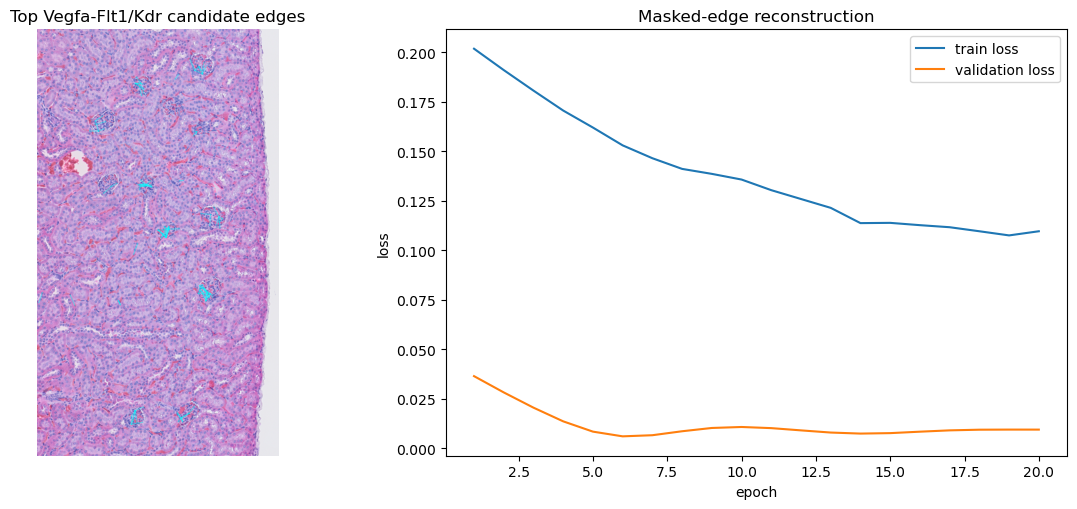

{'case_edges': 1077, 'test_spearman': 0.5704399461168973, 'test_mae': 0.08898986298895885, 'interpretation': '模型指标衡量被隐藏证据的重建能力；候选通讯仍需蛋白、扰动或成像实验验证。'}


In [5]:
top_case = case_edges.nlargest(100, 'gnn_score')  # 只绘制最高分的100条边，避免图面拥挤
coord = cells.set_index('ID')[['X', 'Y']].copy()  # 建立细胞编号到坐标的查找表
coord['X'] *= scale_x; coord['Y'] *= scale_y  # 将原始坐标同步缩放到H&E预览尺寸
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))  # 同时展示空间关系与训练记录
axes[0].imshow(he_image)  # 显示组织背景
for row in top_case.itertuples():  # 逐条绘制有方向的候选边
    start = coord.loc[row.src_cell_id].to_numpy()  # 读取发送细胞坐标
    end = coord.loc[row.dst_cell_id].to_numpy()  # 读取接收细胞坐标
    axes[0].plot([start[0], end[0]], [start[1], end[1]], color='cyan', alpha=.38, linewidth=.9)  # 绘制局部连线
axes[0].set_title('Top Vegfa-Flt1/Kdr candidate edges')  # 标明空间图内容
axes[0].set_xlim(*view_x); axes[0].set_ylim(view_y[1], view_y[0])  # 与数据概览使用相同组织视野
axes[0].axis('off')  # 隐藏像素坐标刻度
axes[1].plot(history['epoch'], history['loss'], label='train loss')  # 显示训练损失
axes[1].plot(history['epoch'], history['validation_loss'], label='validation loss')  # 显示验证损失
axes[1].set(xlabel='epoch', ylabel='loss', title='Masked-edge reconstruction')  # 标注训练曲线
axes[1].legend()  # 显示曲线图例
fig.tight_layout()  # 调整图像边距
fig.savefig(OUT / 'task4_spatial_and_training.png', dpi=170)  # 保存最终结果图
plt.show()  # 在 Notebook 中显示结果
result_summary = {  # 保存可机器读取的关键结论
    'case_edges': int(len(case_edges)),  # 记录案例候选边数量
    'test_spearman': float(metrics['test']['spearman']),  # 记录独立遮边测试排序相关
    'test_mae': float(metrics['test']['mae']),  # 记录独立遮边测试误差
    'interpretation': '模型指标衡量被隐藏证据的重建能力；候选通讯仍需蛋白、扰动或成像实验验证。',  # 写明证据边界
}
(OUT / 'result_summary.json').write_text(json.dumps(result_summary, ensure_ascii=False, indent=2), encoding='utf-8')  # 保存结果摘要
print(result_summary)  # 显示最终结果
